In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [24]:
df = pd.read_csv("../data/ethiopia.csv")

print(df.shape)
print(df.columns)   # 👈 critical checkpoint

df["Country"] = "Ethiopia"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["DATE"].dt.month

(4108, 12)
Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'],
      dtype='str')


In [39]:
df = df.replace(-999, np.nan)

dup_count = df.duplicated().sum()
df = df.drop_duplicates()

print("Duplicates removed:", dup_count)

Duplicates removed: 0


In [ ]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [ ]:
missing_pct = df.isna().mean() * 100
missing_pct.sort_values(ascending=False)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [40]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = df[cols].apply(zscore)

outliers = (z.abs() > 3)

print(outliers.sum())

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


In [41]:
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

df = df.ffill()

df = df[df.isna().mean(axis=1) < 0.3]

In [42]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

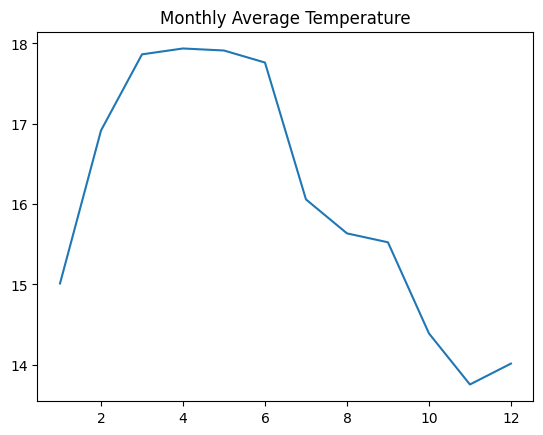

Warmest month: 4
Coldest month: 11


In [32]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature")
plt.show()

print("Warmest month:", monthly_temp.idxmax())
print("Coldest month:", monthly_temp.idxmin())

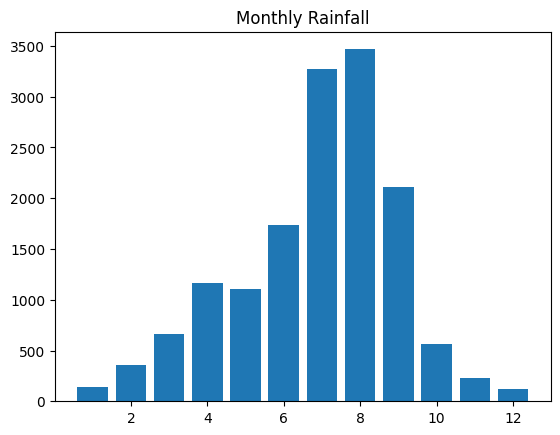

In [ ]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Avg Temperature")
plt.show()

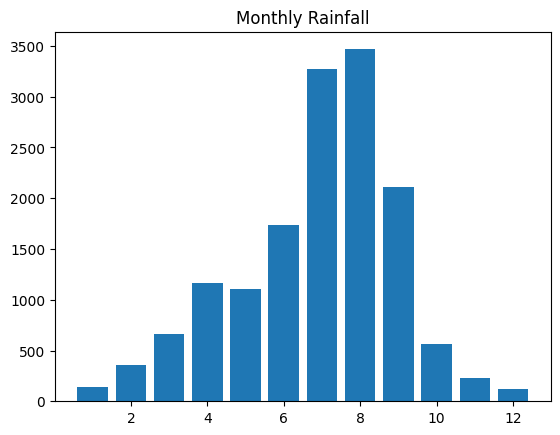

In [43]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.show()

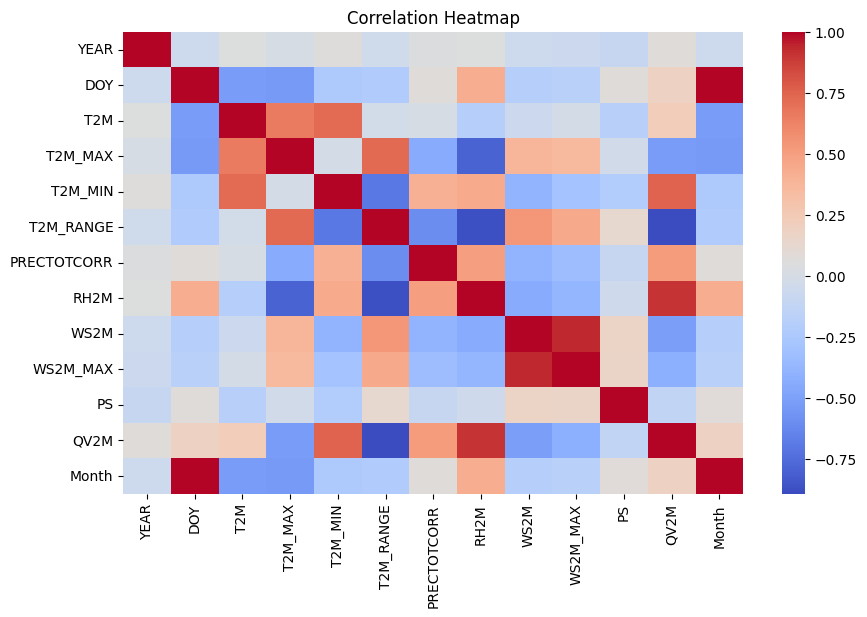

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

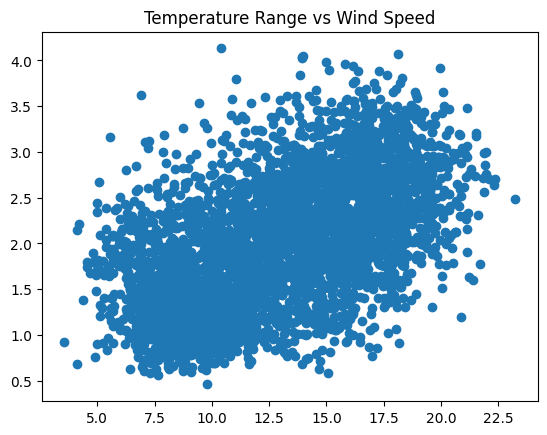

In [ ]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("T2M vs RH2M")
plt.show()

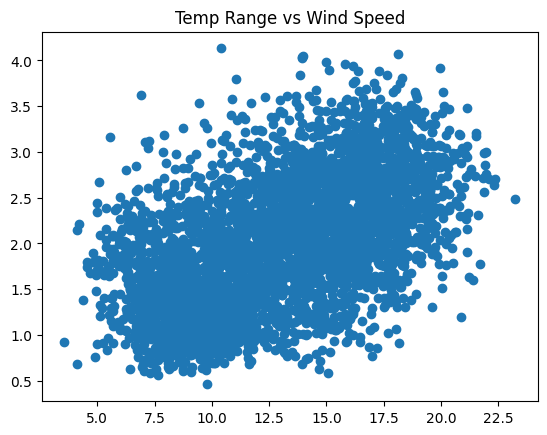

In [45]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temp Range vs Wind Speed")
plt.show()

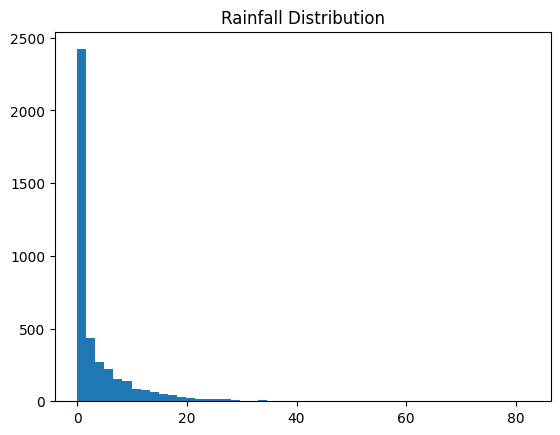

In [46]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

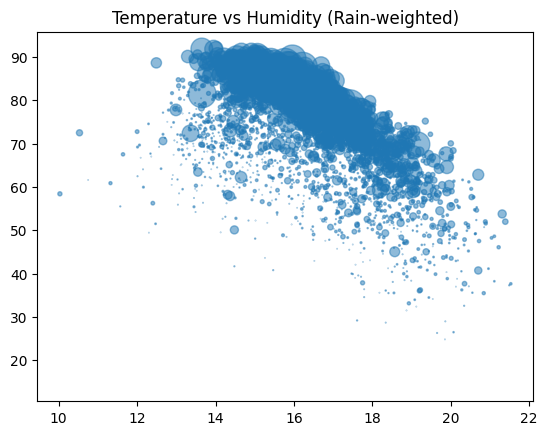

In [47]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 10,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Rain-weighted)")
plt.show()